### OPCKD Exploring Data

### Setup

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
output_dir = '../images'
os.makedirs(output_dir, exist_ok=True)

In [3]:
def save_plot(fig, filename):
    file_path = os.path.join(output_dir, filename)
    fig.savefig(file_path, bbox_inches='tight')
    print(f'Image saved as {file_path}')

#### Recovering the data

In [4]:
import pandas as pd

In [5]:
ML_ROOT_DIR = "../../ml-models"
FOLDER_ID = "datasets"
LDD_PATH = os.path.join(ML_ROOT_DIR, FOLDER_ID)

In [6]:
def load_opcdk_data(ldd_path = LDD_PATH):
  csv_path = os.path.join(ldd_path, 'OsteoporosisPredictionInCKD.csv')
  return pd.read_csv(csv_path)

#### Understanding the data structure

In [7]:
opcdk = load_opcdk_data()

In [8]:
opcdk.head()

,Cre,Gender,eGFR,Osteoporosis,Age,Weight,Height,BMI,Albumin,Calcium,...,CVA,Cataract,Fragility fracture hx,T1DM,Osteogenesis Imperfecta,Hyperthyroidism,Hypogonadism,Premature ovarian insufficiency,Malnutrition,Chronic liver disease
0,1.12,0,58.75,1,53.2,42.7,155.1,17.8,4.2,9.4,...,0,1,0,0,0,0,0,0,0,0
1,1.81,1,38.87,1,73.5,NaN,NaN,NaN,3.5,8.8,...,0,0,0,0,0,0,0,0,0,0
2,1.05,0,52.28,1,84.4,NaN,NaN,NaN,2.9,7.6,...,0,0,1,0,0,0,0,0,0,0
3,0.98,0,56.88,1,84.1,NaN,NaN,NaN,3.7,9.5,...,0,0,1,0,0,0,0,0,0,0
4,1.15,0,47.11,1,83.5,62.7,152.3,27.0,NaN,8.8,...,1,0,1,0,0,0,0,0,0,0


In [9]:
opcdk.columns

Index(['Cre', 'Gender', 'eGFR', 'Osteoporosis', 'Age', 'Weight', 'Height',
       'BMI', 'Albumin', 'Calcium', 'Phosphate', 'ALP', 'iPTH', 'HbA1c',
       'Glucose', 'WBC', 'HGB', 'Steroid usage', 'OA', 'RA', 'DM', 'HTN',
       'CVA', 'Cataract', 'Fragility fracture hx', 'T1DM',
       'Osteogenesis Imperfecta', 'Hyperthyroidism', 'Hypogonadism',
       'Premature ovarian insufficiency', 'Malnutrition',
       'Chronic liver disease'],
      dtype='object')

In [10]:
columns_to_drop = ['Weight', 'Height', 'iPTH', 'Premature ovarian insufficiency']
opcdk_clean = opcdk.drop(columns=columns_to_drop, errors='ignore')

print(f"Shape após remoção: {opcdk_clean.shape}")

Shape após remoção: (6614, 28)


In [11]:
opcdk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6614 entries, 0 to 6613
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Cre                              6614 non-null   float64
 1   Gender                           6614 non-null   int64  
 2   eGFR                             6614 non-null   float64
 3   Osteoporosis                     6614 non-null   int64  
 4   Age                              6614 non-null   float64
 5   Weight                           4566 non-null   float64
 6   Height                           4326 non-null   float64
 7   BMI                              4311 non-null   float64
 8   Albumin                          5945 non-null   float64
 9   Calcium                          6142 non-null   float64
 10  Phosphate                        4522 non-null   float64
 11  ALP                              5542 non-null   float64
 12  iPTH                

In [12]:
opcdk = opcdk.drop(columns=['iPTH'])

In [13]:
binary_cols = [
    col for col in opcdk.columns
    if opcdk[col].dropna().isin([0, 1]).all()
]

In [14]:
opcdk[binary_cols] = opcdk[binary_cols].fillna(0)

In [15]:
opcdk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6614 entries, 0 to 6613
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Cre                              6614 non-null   float64
 1   Gender                           6614 non-null   int64  
 2   eGFR                             6614 non-null   float64
 3   Osteoporosis                     6614 non-null   int64  
 4   Age                              6614 non-null   float64
 5   Weight                           4566 non-null   float64
 6   Height                           4326 non-null   float64
 7   BMI                              4311 non-null   float64
 8   Albumin                          5945 non-null   float64
 9   Calcium                          6142 non-null   float64
 10  Phosphate                        4522 non-null   float64
 11  ALP                              5542 non-null   float64
 12  HbA1c               

In [16]:
# Visualizing the distribution of the target variable
opcdk['Osteoporosis'].value_counts()

Osteoporosis
1    4526
0    2088
Name: count, dtype: int64

In [17]:
opcdk.describe()

,Cre,Gender,eGFR,Osteoporosis,Age,Weight,Height,BMI,Albumin,Calcium,...,CVA,Cataract,Fragility fracture hx,T1DM,Osteogenesis Imperfecta,Hyperthyroidism,Hypogonadism,Premature ovarian insufficiency,Malnutrition,Chronic liver disease
count,6614.000000,6614.000000,6614.000000,6614.000000,6614.000000,4566.000000,4326.000000,4311.000000,5945.000000,6142.000000,...,6614.000000,6614.000000,6614.000000,6614.000000,6614.0,6614.000000,6614.000000,6614.000000,6614.000000,6614.000000
mean,2.316964,0.299667,41.268966,0.684306,73.260553,59.187735,155.747619,24.355486,3.822439,8.947639,...,0.266556,0.375416,0.510886,0.012398,0.0,0.082855,0.011037,0.001058,0.013607,0.321439
std,2.738952,0.458147,17.095048,0.464827,12.729108,12.150316,9.156773,4.331088,0.571244,0.847437,...,0.442192,0.484267,0.499919,0.110662,0.0,0.275683,0.104485,0.032518,0.115864,0.467064
min,0.890000,0.000000,2.090000,0.000000,21.800000,31.300000,100.400000,12.500000,1.100000,4.300000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.120000,0.000000,32.212500,0.000000,66.300000,50.800000,149.800000,21.400000,3.500000,8.500000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.330000,0.000000,47.335000,1.000000,75.300000,58.400000,155.100000,24.100000,3.900000,9.000000,...,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.800000,1.000000,54.977500,1.000000,82.500000,66.000000,161.400000,26.900000,4.200000,9.400000,...,1.000000,1.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000
max,20.480000,1.000000,59.990000,1.000000,105.100000,165.000000,200.000000,57.600000,5.100000,15.500000,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
# histogram for numeric attributes
%matplotlib inline
import matplotlib.pyplot as plt

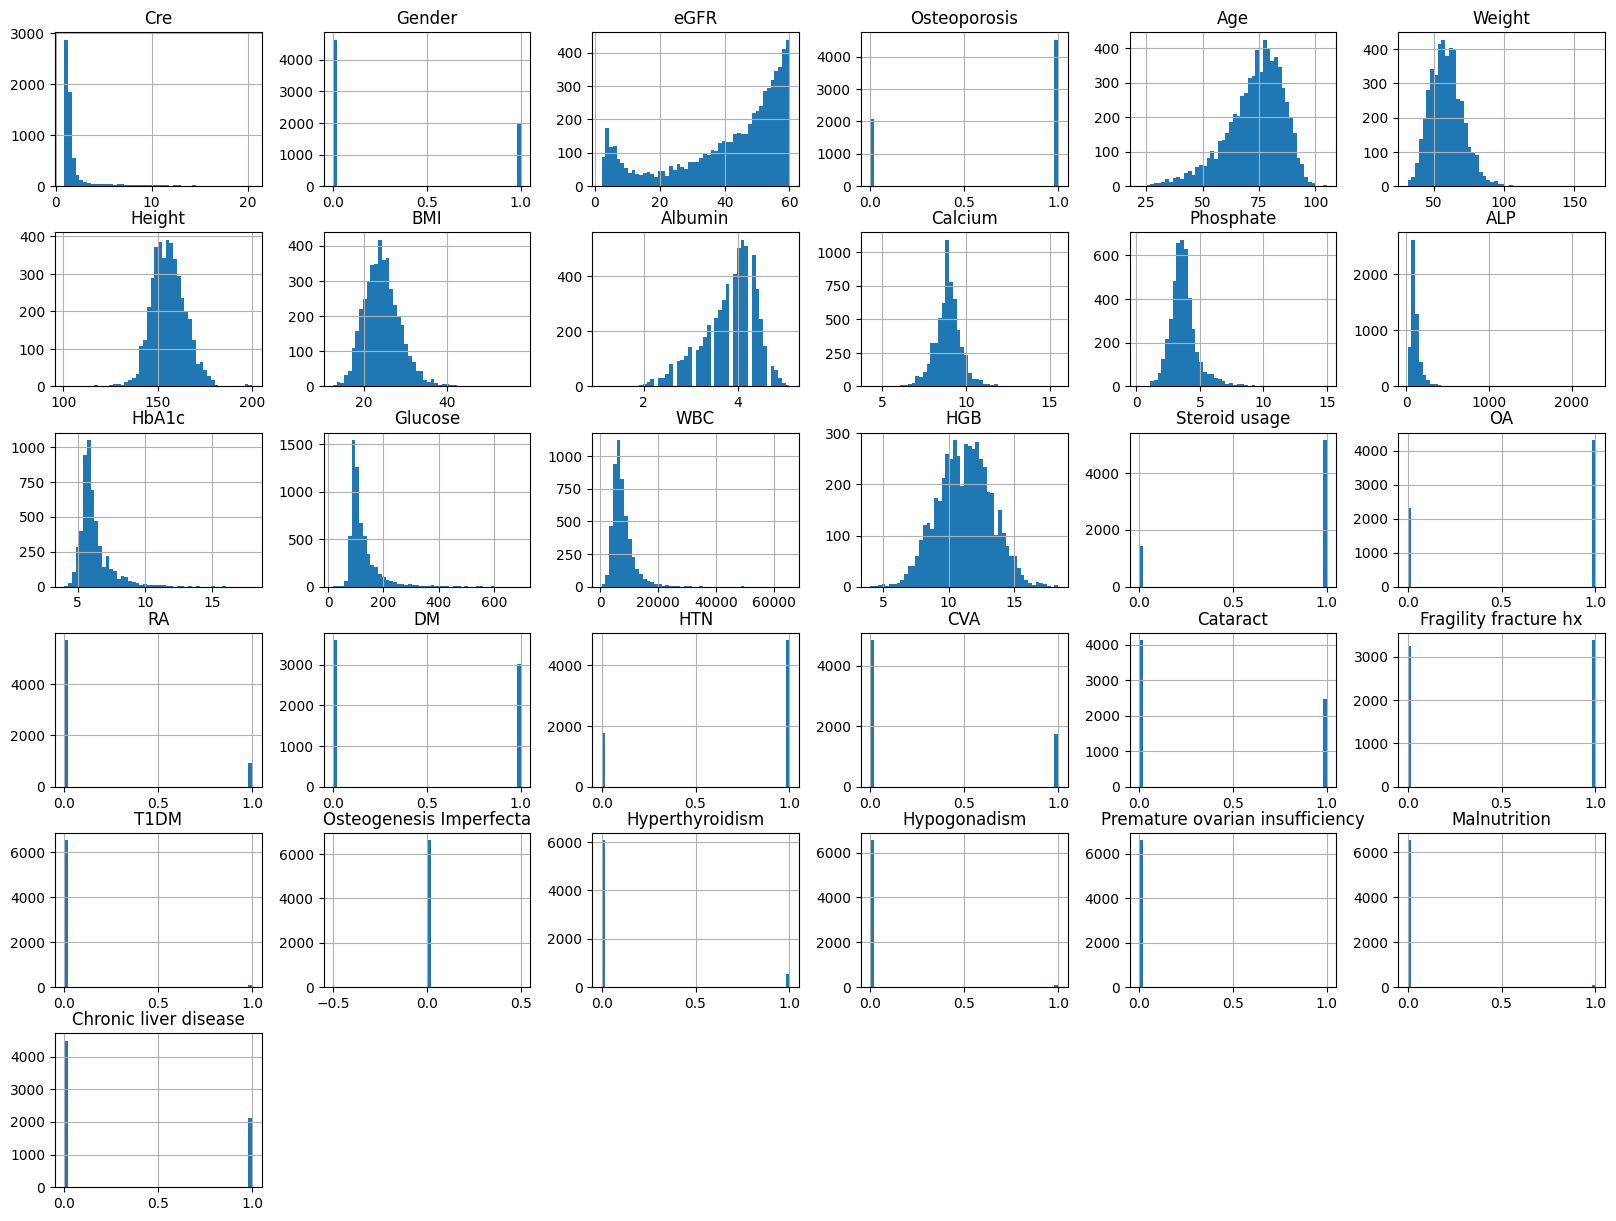

In [19]:
opcdk.hist(bins=50, figsize=(20, 15))
plt.show()

#### Exploring and visualizing data

In [20]:
import seaborn as sns

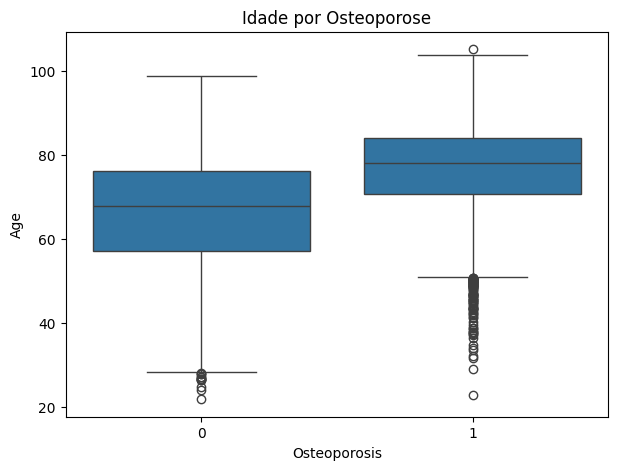

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(data=opcdk, x="Osteoporosis", y="Age")
plt.title("Idade por Osteoporose")
plt.show()

O gráfico mostra que pessoas com osteoporose tendem a ser mais velhas do que as sem osteoporose. Isso vai na mesma direção do que se observa em estudos: a idade é um dos principais fatores de risco para osteoporose.

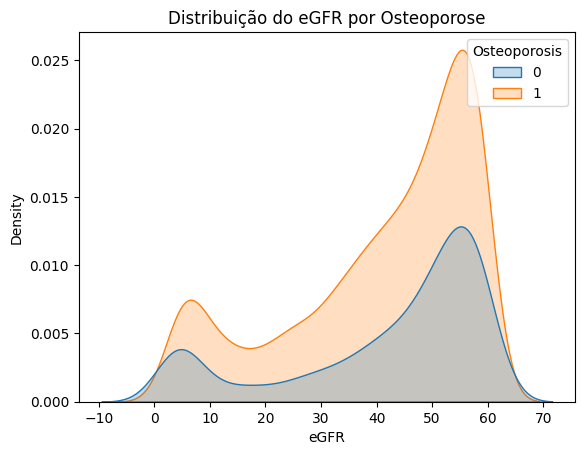

In [22]:
sns.kdeplot(data=opcdk, x="eGFR", hue="Osteoporosis", fill=True)
plt.title("Distribuição do eGFR por Osteoporose")
plt.show()

Em geral, os valores de eGFR são parecidos entre quem tem e quem não tem osteoporose, com uma leve tendência a valores um pouco menores no grupo com osteoporose em parte da distribuição. Isso se conecta ao fato de que função renal (eGFR) e saúde óssea podem se relacionar, mas nem sempre a piora renal é um fator independente de risco para osteoporose depois de ajustar por idade e outros fatores.

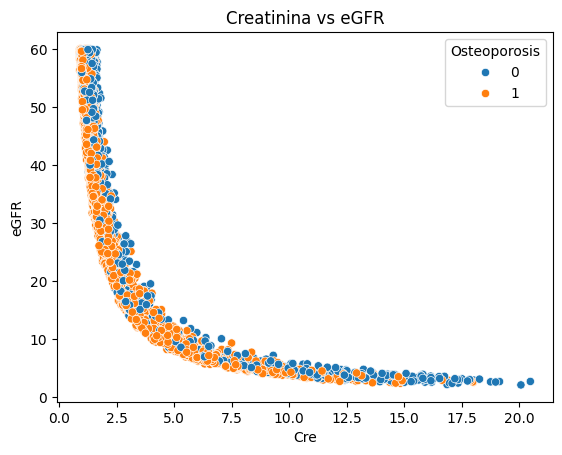

In [23]:
sns.scatterplot(data=opcdk, x="Cre", y="eGFR", hue="Osteoporosis")
plt.title("Creatinina vs eGFR")
plt.show()

Conforme a creatinina aumenta, o eGFR cai de forma acentuada, e isso acontece de modo muito semelhante nos grupos com e sem osteoporose. A nuvem de pontos laranja (osteoporose = 1) e azul (osteoporose = 0) praticamente se sobrepõe, sugerindo que a relação creatinina–eGFR não é diferente entre os grupos.

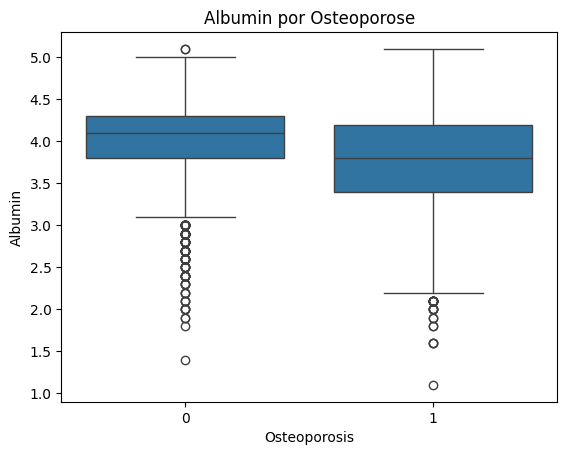

In [24]:
sns.boxplot(data=opcdk, x="Osteoporosis", y="Albumin")
plt.title("Albumin por Osteoporose")
plt.show()

Os níveis de albumina são bem parecidos entre os grupos com e sem osteoporose, com mediana em torno de 3,8–4,0 g/dL nos dois casos. A principal diferença visual está na cauda inferior, há mais valores muito baixos (hipoalbuminemia) no grupo sem osteoporose, mas também existem alguns no grupo com osteoporose.

O uso de esteroides é a condição mais comum, seguido de hipertensão, osteoartrite e histórico de fratura por fragilidade. Isso é relevante porque várias delas são fatores de risco clássicos ou associados para osteoporose e fraturas.

#### Handling missing values

In [25]:
# Análise de valores faltantes
missing_info = pd.DataFrame({
    'Column': opcdk_clean.columns,
    'Missing_Count': opcdk_clean.isnull().sum(),
    'Missing_Percentage': (opcdk_clean.isnull().sum() / len(opcdk_clean) * 100).round(2)
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print("\nValores faltantes por coluna:")
print(missing_info)


Valores faltantes por coluna:
              Column  Missing_Count  Missing_Percentage
BMI              BMI           2303               34.82
Phosphate  Phosphate           2092               31.63
WBC              WBC           1545               23.36
HGB              HGB           1526               23.07
HbA1c          HbA1c           1323               20.00
ALP              ALP           1072               16.21
Albumin      Albumin            669               10.11
Glucose      Glucose            586                8.86
Calcium      Calcium            472                7.14


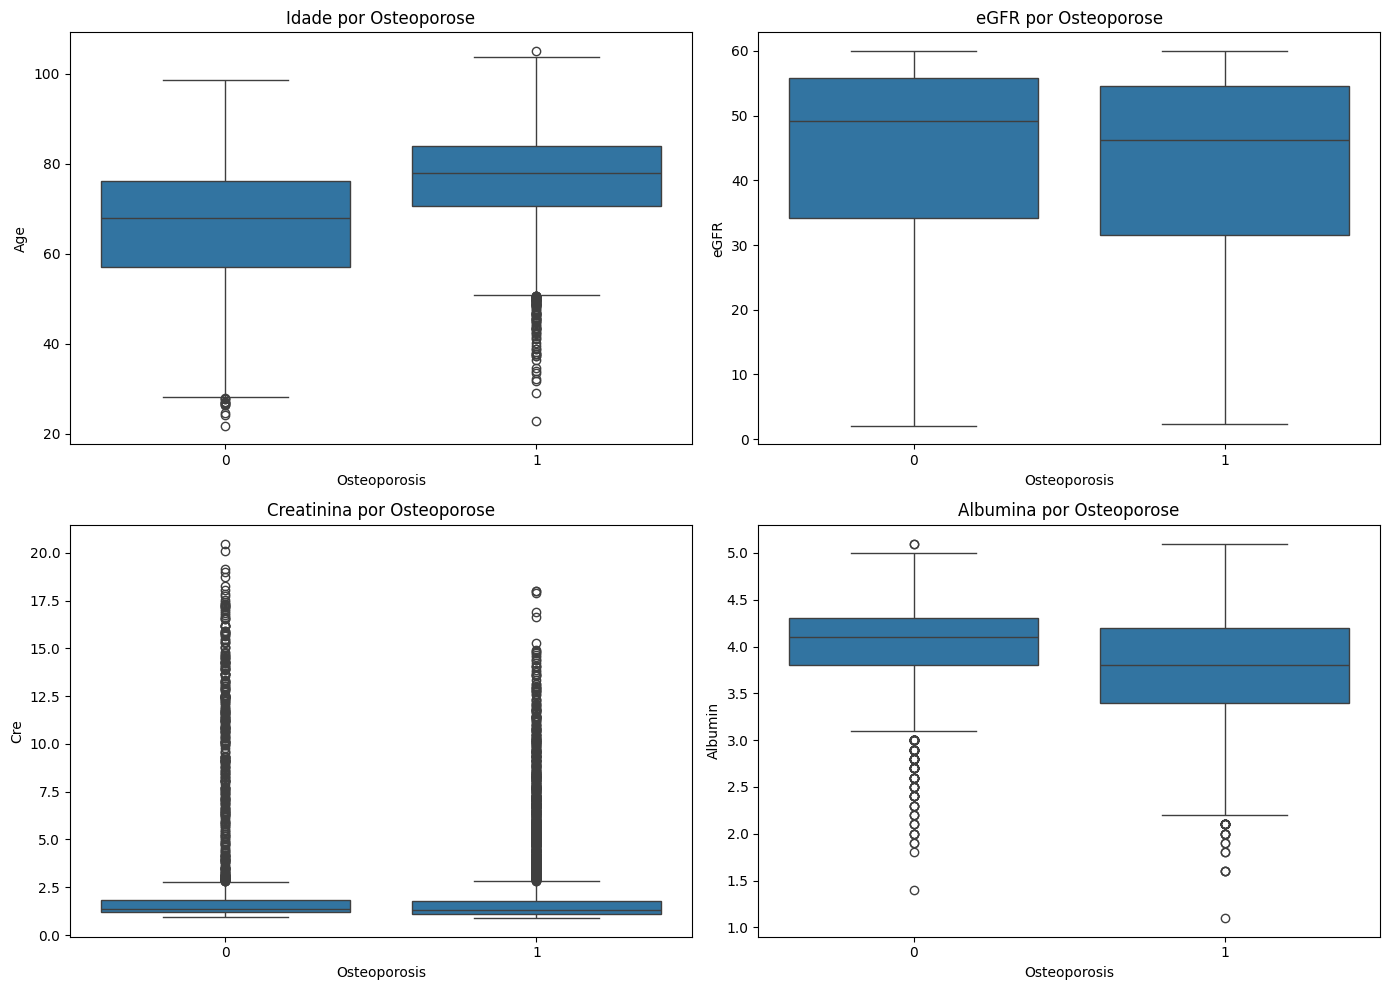

In [26]:
# Análise da variável target vs features numéricas importantes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=opcdk_clean, x="Osteoporosis", y="Age", ax=axes[0,0])
axes[0,0].set_title("Idade por Osteoporose")

sns.boxplot(data=opcdk_clean, x="Osteoporosis", y="eGFR", ax=axes[0,1])
axes[0,1].set_title("eGFR por Osteoporose")

sns.boxplot(data=opcdk_clean, x="Osteoporosis", y="Cre", ax=axes[1,0])
axes[1,0].set_title("Creatinina por Osteoporose")

sns.boxplot(data=opcdk_clean, x="Osteoporosis", y="Albumin", ax=axes[1,1])
axes[1,1].set_title("Albumina por Osteoporose")

plt.tight_layout()
plt.show()

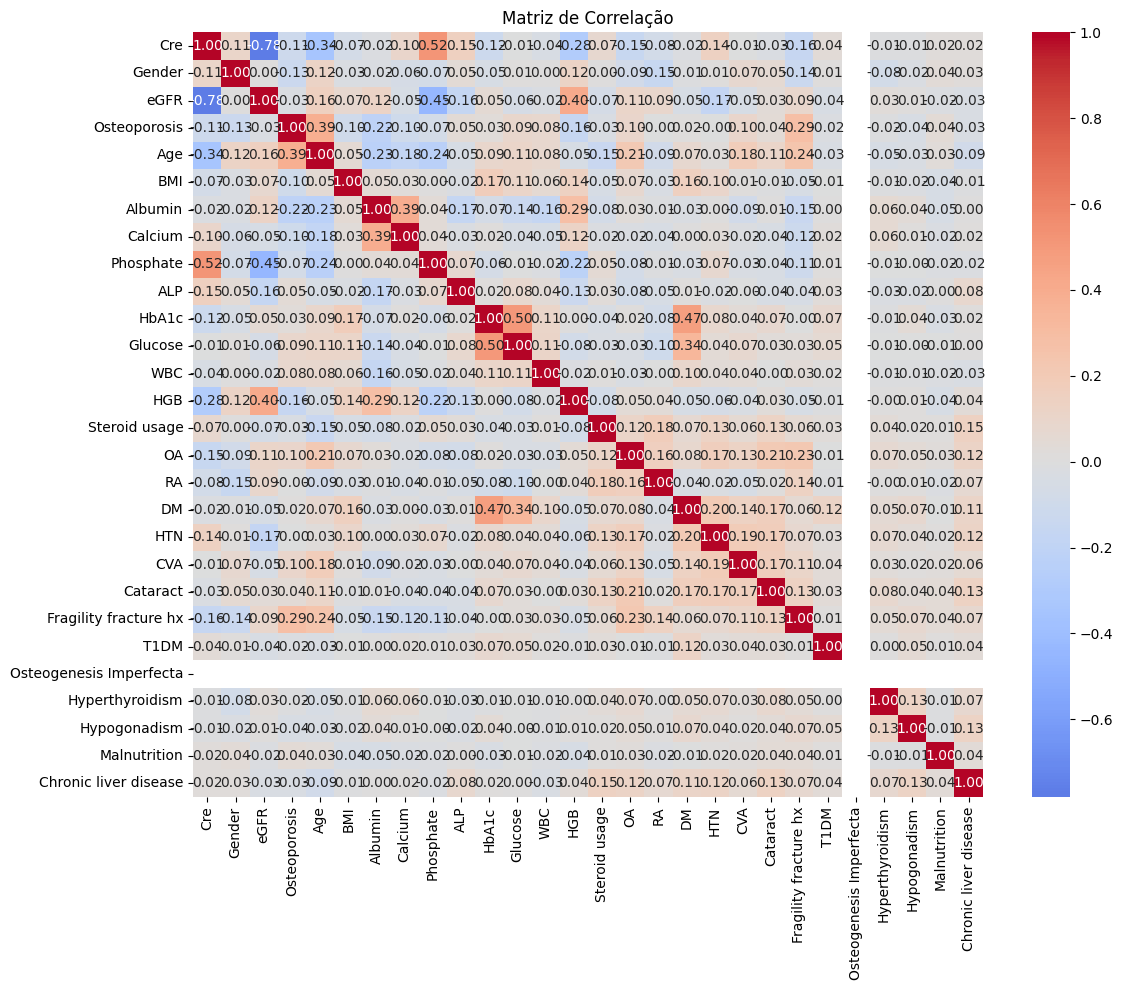

In [27]:
# Correlation matrix
numeric_cols = opcdk_clean.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
correlation_matrix = opcdk_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

In [28]:
# Separar target e features ANTES de qualquer processamento
X = opcdk_clean.drop(columns=['Osteoporosis'])
y = opcdk_clean['Osteoporosis'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape: (6614, 27)
y shape: (6614,)
y distribution:
Osteoporosis
1    4526
0    2088
Name: count, dtype: int64


In [29]:
# Identificar tipos de features
binary_features = []
numeric_features = []
categorical_features = []

for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        # Verificar se é binária
        unique_vals = X[col].dropna().unique()
        if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_features.append(col)
        else:
            numeric_features.append(col)
    else:
        categorical_features.append(col)

print(f"Features binárias ({len(binary_features)}): {binary_features}")
print(f"Features numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Features categóricas ({len(categorical_features)}): {categorical_features}")

Features binárias (15): ['Gender', 'Steroid usage', 'OA', 'RA', 'DM', 'HTN', 'CVA', 'Cataract', 'Fragility fracture hx', 'T1DM', 'Osteogenesis Imperfecta', 'Hyperthyroidism', 'Hypogonadism', 'Malnutrition', 'Chronic liver disease']
Features numéricas (12): ['Cre', 'eGFR', 'Age', 'BMI', 'Albumin', 'Calcium', 'Phosphate', 'ALP', 'HbA1c', 'Glucose', 'WBC', 'HGB']
Features categóricas (0): []


In [30]:
# Preencher valores faltantes em features binárias com 0 (assumindo ausência da condição)
X[binary_features] = X[binary_features].fillna(0)
print(f"Valores faltantes preenchidos em {len(binary_features)} features binárias")

Valores faltantes preenchidos em 15 features binárias


In [31]:
from sklearn.model_selection import train_test_split

# Split ANTES de qualquer imputação/scaling para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test distribution:\n{y_test.value_counts()}")

X_train shape: (5291, 27)
X_test shape: (1323, 27)
y_train distribution:
Osteoporosis
1    3621
0    1670
Name: count, dtype: int64
y_test distribution:
Osteoporosis
1    905
0    418
Name: count, dtype: int64


In [32]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Pipeline para features numéricas: imputar + escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para features categóricas: imputar apenas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combinar transformações (features binárias passam direto)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# FIT apenas no treino, TRANSFORM em ambos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Converter de volta para DataFrame
feature_names = numeric_features + binary_features + categorical_features
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (5291, 27)
X_test_processed shape: (1323, 27)


In [33]:
# Verificar se há valores faltantes após preprocessing
print("\nValores faltantes após preprocessing:")
print(f"X_train: {X_train_processed.isnull().sum().sum()}")
print(f"X_test: {X_test_processed.isnull().sum().sum()}")


Valores faltantes após preprocessing:
X_train: 0
X_test: 0


In [34]:
from imblearn.over_sampling import SMOTE

print("Distribuição ANTES do SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print("\nDistribuição DEPOIS do SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

print(f"\nX_train_balanced shape: {X_train_balanced.shape}")

Distribuição ANTES do SMOTE:
Osteoporosis
1    3621
0    1670
Name: count, dtype: int64

Distribuição DEPOIS do SMOTE:
Osteoporosis
0    3621
1    3621
Name: count, dtype: int64

X_train_balanced shape: (7242, 27)



Top 15 features mais importantes:
                  feature  importance
2                     Age    0.170579
20  Fragility fracture hx    0.153570
3                     BMI    0.085193
4                 Albumin    0.067350
0                     Cre    0.050914
7                     ALP    0.048270
1                    eGFR    0.047733
12                 Gender    0.044959
9                 Glucose    0.044820
11                    HGB    0.044339
5                 Calcium    0.037576
10                    WBC    0.036115
6               Phosphate    0.033670
8                   HbA1c    0.032924
18                    CVA    0.024332


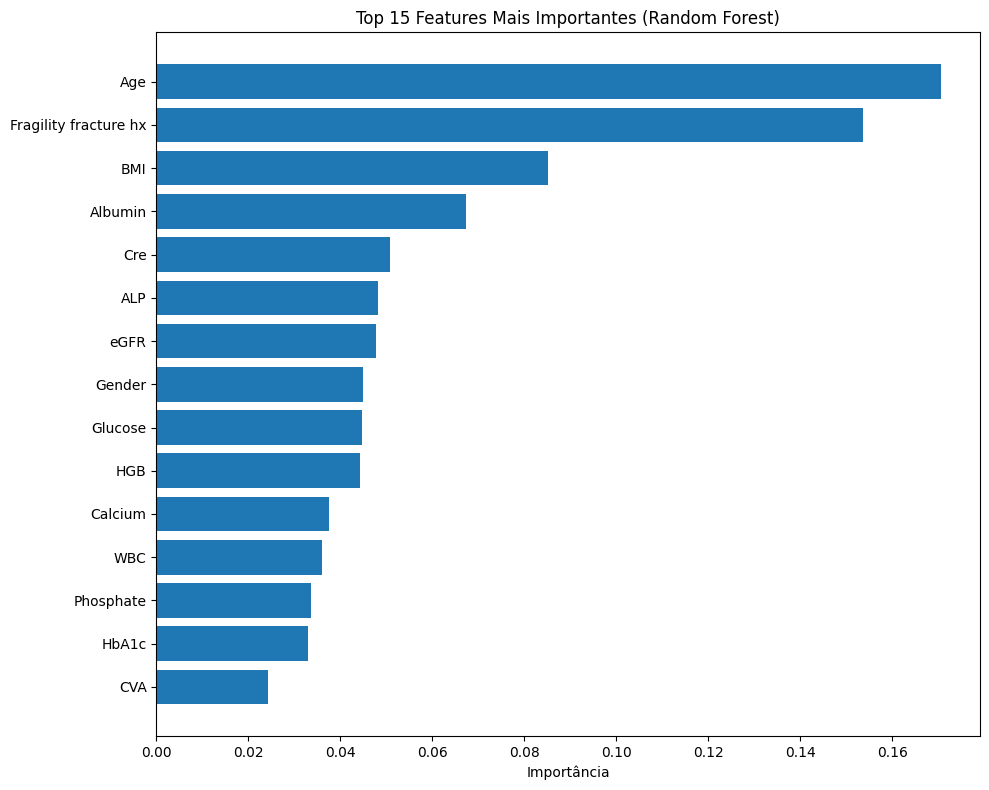

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Treinar RF simples para ver importâncias
rf_simple = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_simple.fit(X_train_balanced, y_train_balanced)

# Feature importances
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_simple.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features mais importantes:")
print(feature_importance.head(15))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Importância')
plt.title('Top 15 Features Mais Importantes (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
# Criar diretório se não existir
output_path = "../datasets/opckd_datasets/"
os.makedirs(output_path, exist_ok=True)

# Salvar datasets
X_train_balanced.to_csv(f"{output_path}X_train.csv", index=False)
X_test_processed.to_csv(f"{output_path}X_test.csv", index=False)
pd.Series(y_train_balanced).to_csv(f"{output_path}y_train.csv", index=False, header=['Osteoporosis'])
pd.Series(y_test).to_csv(f"{output_path}y_test.csv", index=False, header=['Osteoporosis'])

print("✅ Datasets salvos com sucesso!")
print(f"   - X_train: {X_train_balanced.shape}")
print(f"   - X_test: {X_test_processed.shape}")
print(f"   - y_train: {len(y_train_balanced)}")
print(f"   - y_test: {len(y_test)}")

✅ Datasets salvos com sucesso!
   - X_train: (7242, 27)
   - X_test: (1323, 27)
   - y_train: 7242
   - y_test: 1323


In [37]:
# Verificar que os dados estão corretos
print("Verificação final dos dados:")
print(f"\n1. Mesmos nomes de features: {list(X_train_balanced.columns) == list(X_test_processed.columns)}")
print(f"2. Sem valores faltantes no treino: {X_train_balanced.isnull().sum().sum() == 0}")
print(f"3. Sem valores faltantes no teste: {X_test_processed.isnull().sum().sum() == 0}")
print(f"4. Target balanceado no treino: {pd.Series(y_train_balanced).value_counts().to_dict()}")
print(f"5. Target original no teste: {pd.Series(y_test).value_counts().to_dict()}")

Verificação final dos dados:

1. Mesmos nomes de features: True
2. Sem valores faltantes no treino: True
3. Sem valores faltantes no teste: True
4. Target balanceado no treino: {0: 3621, 1: 3621}
5. Target original no teste: {1: 905, 0: 418}
